### Test implementation

In [1]:
import modelskill as ms
import pandas as pd
from pathlib import Path
import mikeio

%load_ext autoreload
%autoreload 2

**Read obs from csv**

In [2]:
# Load obs from csv
csv_file = Path("../tests/testdata/vertical/VerticalProfile_obs1.csv")
metadata = pd.read_csv(csv_file, nrows=2, header=None)
xpos = float(metadata.values[0, 0].split(":")[-1].lstrip())
ypos = float(metadata.values[1, 0].split(":")[-1].lstrip())
obs_1 = pd.read_csv(csv_file, sep=",", comment="#", index_col=0, parse_dates=True)
vo = ms.VerticalObservation(
    obs_1,
    item="salt",
    z_item="z",
    x=xpos,
    y=ypos,
    quantity=ms.Quantity("salinity", "psu"),
)

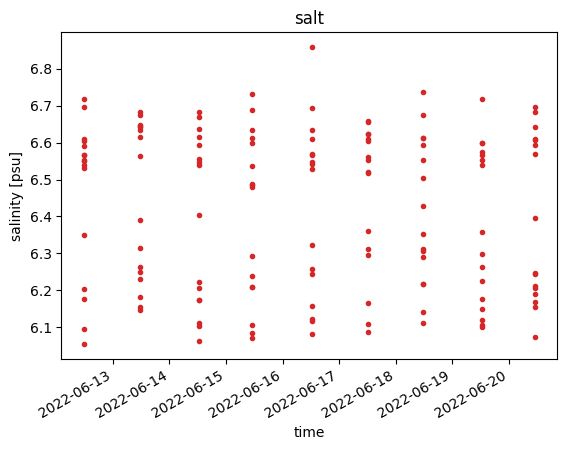

In [3]:
vo.plot()

from https://docs.xarray.dev/en/stable/whats-new.html:

"Calling Dataset.sel() or DataArray.sel() on a 1-dimensional coordinate without an index will 
now automatically create a temporary PandasIndex to perform the selection (GH9703, PR11029)." 

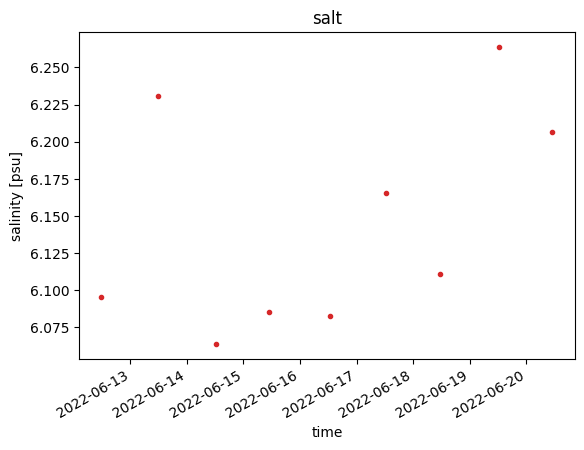

In [4]:
# vo.sel(z=-4).plot() # only works with xarray >= 2026.01.0
ms.VerticalObservation(
    vo.data.where(vo.data["z"] == -4.0, drop=True)
).plot()  # xarray < 2026.01.0

In [5]:
vo.to_dataframe()

,z,salt
time,,
2022-06-12 11:43:00,-30,6.530923
2022-06-12 11:43:00,-28,6.609798
2022-06-12 11:43:00,-26,6.566854
2022-06-12 11:43:00,-24,6.695172
2022-06-12 11:43:00,-22,6.718103
...,...,...
2022-06-20 11:06:00,-8,6.246086
2022-06-20 11:06:00,-6,6.168087
2022-06-20 11:06:00,-4,6.206396


**Read model**

In [6]:
fn = "../tests/testdata/vertical/VerticalModel_at_obs.dfs0"
ms.model_result(fn, z_item="z", name="vmod", gtype="vertical", item="Salinity")

<VerticalModelResult>: vmod
Time: 2022-06-12 00:00:00 - 2022-06-20 22:00:00
Quantity: Salinity [PSU]

In [7]:
# Read model from dfs0 path
vm = ms.VerticalModelResult(
    "../tests/testdata/vertical/VerticalModel_at_obs.dfs0", item="Salinity"
)
# Read model from dfs0 dataset
vm = ms.VerticalModelResult(
    mikeio.read("../tests/testdata/vertical/VerticalModel_at_obs.dfs0"), item="Salinity"
)

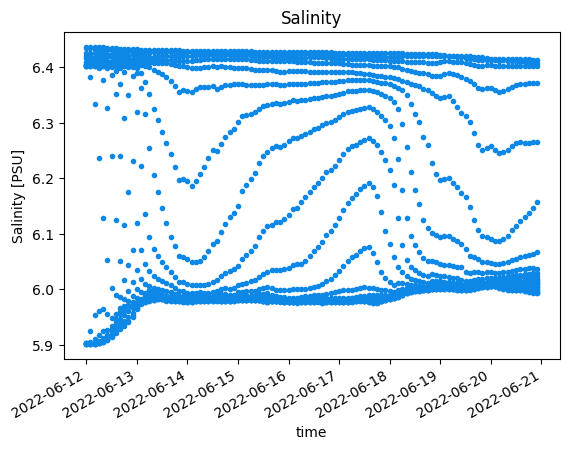

In [8]:
vm.plot()

Read from dfsu and extract

In [9]:
dfsum = ms.DfsuModelResult(
    "../tests/testdata/vertical/sigma_z_coast.dfsu", item="Salinity"
)
dfsum.extract(vo)

<VerticalModelResult>: sigma_z_coast
Time: 2022-06-12 00:00:00 - 2022-06-20 22:00:00
Quantity: Salinity [PSU]

**Test below**

**Matching**

In [10]:
cmp = ms.match(vo, vm)
cmp

<Comparer>
Quantity: salinity [psu]
Observation: salt, n_points=108
Model(s):
0: Salinity

### Working directly with standard comparer

**Overall skill and plots**

In [11]:
cmp.skill()

,n,bias,rmse,urmse,mae,cc,si,r2
observation,,,,,,,,
salt,108,-0.197348,0.20948,0.070255,0.197348,0.940359,0.010997,-0.030702


<Axes: title={'center': 'Salinity vs salt'}, xlabel='Observation, salinity [psu]', ylabel='Model, salinity [psu]'>

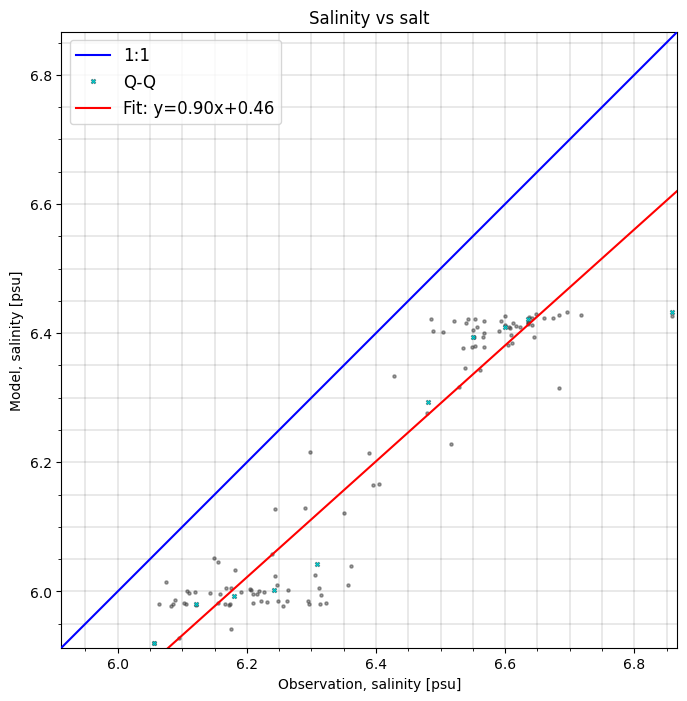

In [12]:
cmp.plot.scatter()

**Slice comparer**

In [13]:
cmp_deep = cmp.where(cmp.data['z']<-10).rename({cmp.name: "deep"})
cmp_surface = cmp.where(cmp.data['z']>=-10).rename({cmp.name: "surface"})
cmp_1m = cmp.where(cmp.data['z']==-2).rename({cmp.name: "1m"})
cmps = ms.ComparerCollection([cmp_deep, cmp_surface, cmp_1m])
cmps.skill()

,n,bias,rmse,urmse,mae,cc,si,r2
observation,,,,,,,,
deep,63,-0.194522,0.205873,0.067416,0.194522,0.895853,0.010336,-0.841364
surface,45,-0.201304,0.214428,0.073865,0.201304,0.662412,0.011912,-3.729550
1m,9,-0.187027,0.197700,0.064078,0.187027,0.548066,0.010388,-6.162230


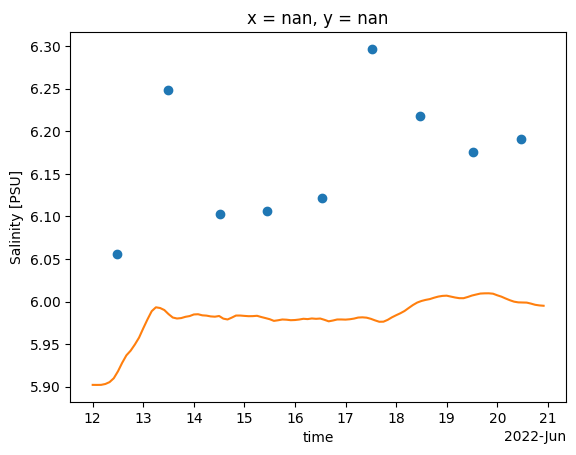

In [ ]:
# How fix this, see issue modelskill#629

d = cmp_1m.raw_mod_data["Salinity"].data
cmp_1m.data["Observation"].plot(marker="o", linestyle="", label="Observation")
d.where((d.z == -1.5),drop=True)['Salinity'].plot()

In [ ]:
# Comparison 847
start=cmp.time[0]-pd.Timedelta("1D")
end=cmp.time[-1]+pd.Timedelta("1D")
d = cmp.data
#d = d.sel(time=d.time.to_index().to_frame().loc[start:end].index)  # type: ignore
d = d.sel(time=slice(start, end))
d

### Vertical specific comparer functions

**Havmöller**

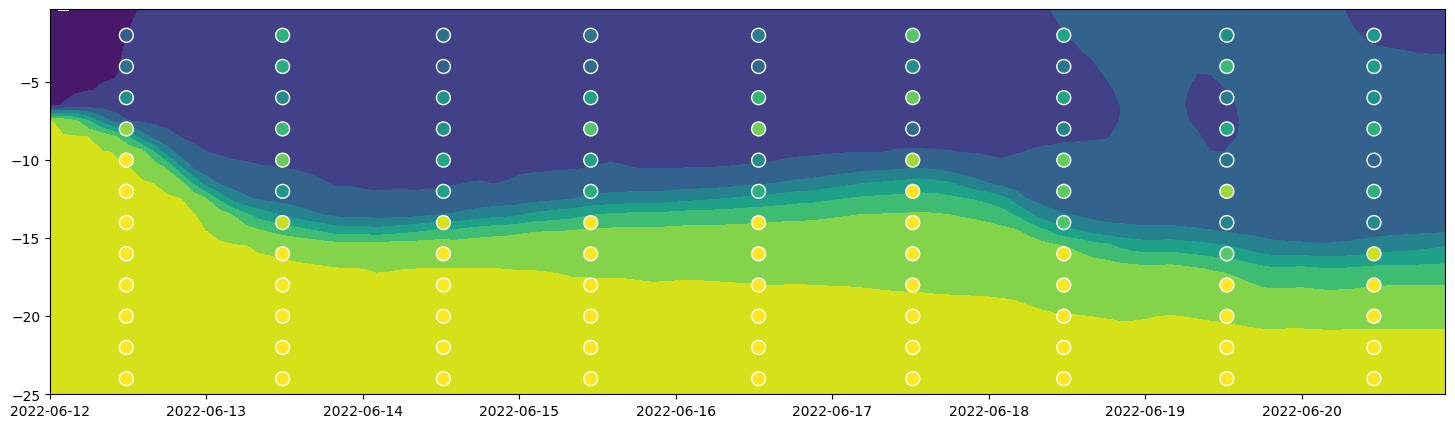

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

cmap = "viridis"

mod_name = "Salinity"
mod_at_obs = cmp.raw_mod_data[mod_name].values
z = cmp.raw_mod_data[mod_name].z
t = cmp.raw_mod_data[mod_name].time
v = mod_at_obs

# Maybe absolute z?

T = np.array(sorted(set(t)))
# assuming equal number of layers
n_layers = len(z) // len(T)

Z = z.reshape(len(T), n_layers)
V = v.reshape(len(T), n_layers)
# time grid
T_grid, Zgrid = np.meshgrid(T, np.arange(n_layers), indexing="ij")
fig, ax = plt.subplots(figsize=(18,5))
ax.contourf(T_grid,Z,V, cmap=cmap) # pcolormesh

# plot obs
# # Overlay observation points
obs = cmp.data["Observation"]
obs_t = set(sorted(obs.time.values))

for date in obs_t:
    obs_on_date = obs[obs.time == date]
    ax.scatter([date]*len(obs_on_date), obs_on_date['z'], 
               c=obs_on_date.values, s=100, edgecolors='white', linewidths=1, 
               cmap=cmap, vmin=V.min(), vmax=V.max())

#ax.invert_yaxis() # if pos z
# ax.set_title(f'{mod_name} profile at {df_to_plt.attrs["station_name"]}')
# ax.invert_yaxis()
# plt.colorbar(c, ax=ax, label=f'{mod_name} (psu)')


**profiles at specific time**

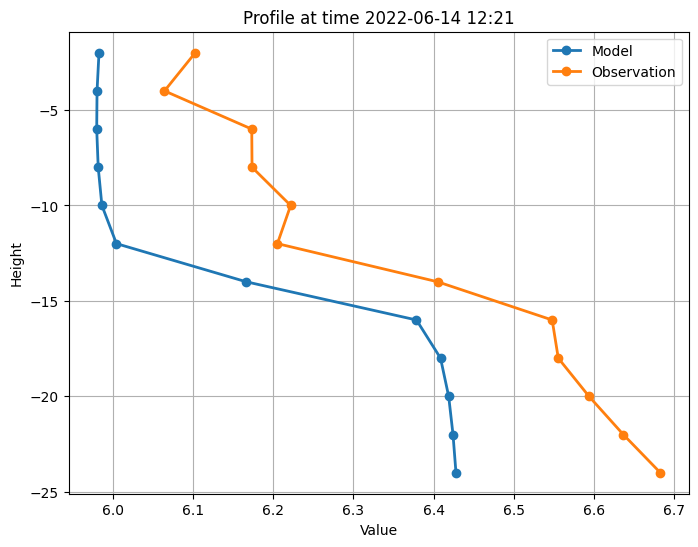

In [ ]:
cmp.data.sel(time=cmp.data.time[0])
cmp_t = cmp.sel(time=cmp.time[0])
# Above creates problem on this row:
#raw_mod_data = {k: v.sel(time=time) for k, v in raw_mod_data.items()} 854 in comparison.py
# Because raw data dont have exact same times

def plot_time(cmp, t):
    fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharey=True)
    data  = cmp.data.sel(time=t)
    mod_v = data[cmp.mod_names[0]].values
    z = data['z'].values
    obs_v = data['Observation'].values
    ax.plot(mod_v, z, 'o-', linewidth=2, label='Model')
    ax.plot(obs_v, z, 'o-', linewidth=2, label='Observation')
    ax.set_xlabel('Value')
    ax.set_ylabel('Height')
    ax.legend()
    ax.grid(True)

    ts = pd.to_datetime(t)
    ax.set_title(f"Profile at time {ts:%Y-%m-%d %H:%M}")

avail_times = cmp.time.unique()
plot_time(cmp, avail_times[2])


**Profile average plots**

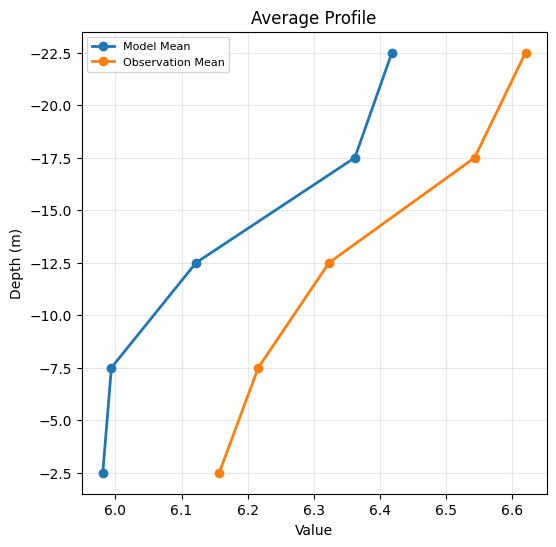

In [ ]:
#input
depth_bins = sorted([0, -5, -10, -15, -20, -25])
depth_labels = ['0-5m', '5-10m', '10-15m', '15-20m', '>20m']
df = cmp.data.to_dataframe()
df['depth_bin'] = pd.cut(df['z'], bins=depth_bins, labels=depth_labels)

df_av = (
    df.groupby("depth_bin", observed=True)
        .agg(
          model_mean=(cmp.mod_names[0], "mean"),
          obs_mean=("Observation", "mean"),
      )
      .round(3)
)

# Plot vertical profile
fig, ax = plt.subplots(1, 1, figsize=(6, 6), sharey=True)

# Get bin centers for plotting
bin_centers = [(depth_bins[i] + depth_bins[i+1])/2 for i in range(len(depth_labels))]

ax.plot(df_av['model_mean'], bin_centers[:len(df_av)], 'o-', linewidth=2, label='Model Mean')
ax.plot(df_av['obs_mean'], bin_centers[:len(df_av)], 'o-', linewidth=2, label='Observation Mean')
ax.set_xlabel('Value')
ax.set_ylabel('Depth (m)')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)
ax.set_title('Average Profile')
ax.legend(fontsize=8)

**Profile statistics plots**

In [ ]:
#input
depth_bins = sorted([0, -5, -10, -15, -20, -25])
depth_labels = ['0-5m', '5-10m', '10-15m', '15-20m', '>20m']

df = cmp.data.to_dataframe()
df['depth_bin'] = pd.cut(df['z'], bins=depth_bins, labels=depth_labels)

df["error"] = df[cmp.mod_names[0]] - df["Observation"]
df["abs_error"] = df["error"].abs()

# Calculate statistics by depth bin
profile_stats = (
    df.groupby("depth_bin", observed=True)
      .agg(
          bias=("error", "mean"),
          std=("error", "std"),
          rmse=("error", lambda x: np.sqrt((x**2).mean())),
          mae=("abs_error", "mean"),
          n=("z", "count"),
      )
      .round(3)
)
profile_stats

,bias,std,rmse,mae,n
depth_bin,,,,,
0-5m,-0.202,0.071,0.214,0.202,27
5-10m,-0.181,0.068,0.193,0.181,18
10-15m,-0.201,0.075,0.214,0.201,27
15-20m,-0.222,0.068,0.232,0.222,18
>20m,-0.175,0.066,0.187,0.175,18


C:\Users\lajo\AppData\Local\Temp\ipykernel_29000\352810279.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=8)


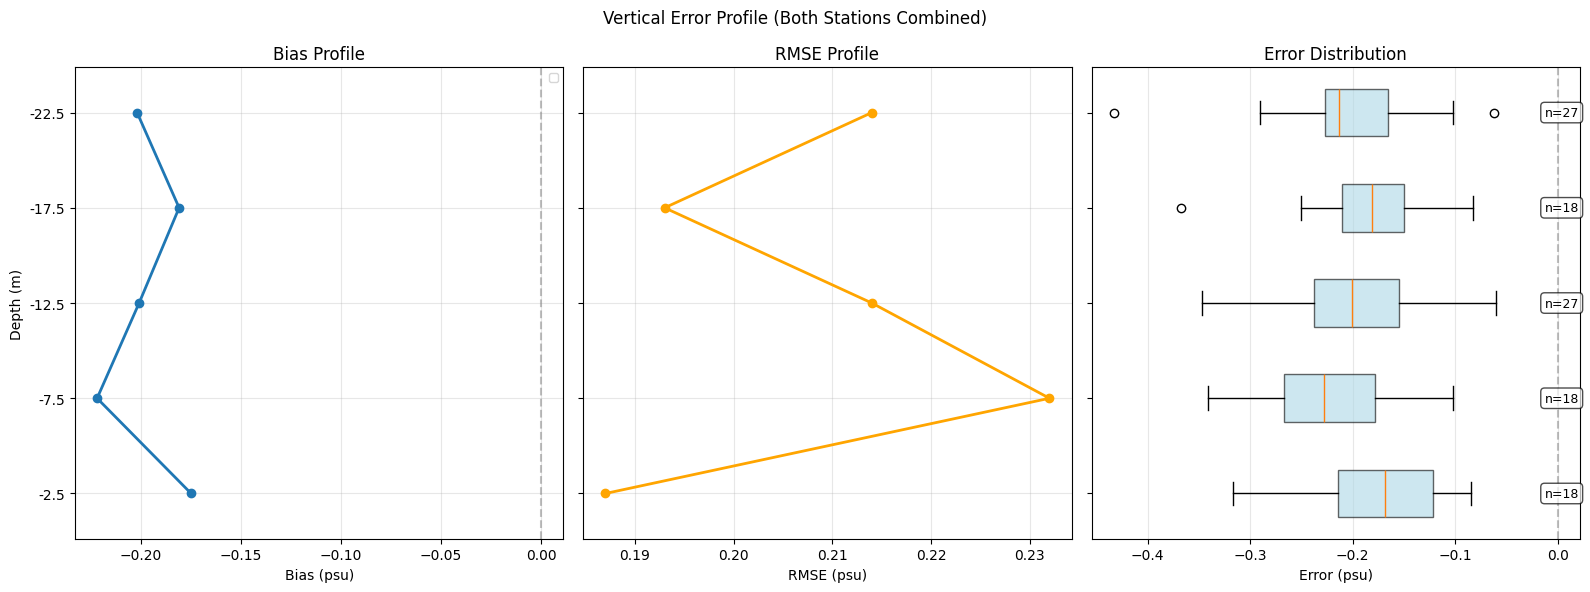

In [ ]:
# Plot vertical profile
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

# Get bin centers for plotting
bin_centers = [(depth_bins[i] + depth_bins[i+1])/2 for i in range(len(depth_labels))]

axes[0].plot(profile_stats['bias'], bin_centers[:len(profile_stats)], 'o-', linewidth=2)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Bias (psu)')
axes[0].set_ylabel('Depth (m)')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Bias Profile')
axes[0].legend(fontsize=8)

axes[1].plot(profile_stats['rmse'], bin_centers[:len(profile_stats)], 'o-', linewidth=2, color='orange')
axes[1].set_xlabel('RMSE (psu)')
axes[1].grid(True, alpha=0.3)
axes[1].set_title('RMSE Profile')

# Boxplot of errors by depth bin
error_by_depth = [df[df['depth_bin'] == label]['error'].values 
                  for label in depth_labels if label in df['depth_bin'].values]
positions = [bin_centers[i] for i in range(len(error_by_depth))]

bp = axes[2].boxplot(error_by_depth, positions=positions, vert=False, widths=2.5,
                      patch_artist=True, showfliers=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.6)

axes[2].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Error (psu)')
axes[2].grid(True, alpha=0.3, axis='x')
axes[2].set_title('Error Distribution')

# Add N observations as text on the right side
for i, (label, pos) in enumerate(zip(profile_stats.index, positions)):
    n_obs = profile_stats.loc[label, 'n']
    axes[2].text(axes[2].get_xlim()[1] * 0.95, pos, f'n={n_obs}', 
                 va='center', ha='right', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', 
                 facecolor='white', alpha=0.7))

plt.suptitle('Vertical Error Profile (Both Stations Combined)')
plt.tight_layout()

### Considerations and ideas for working with 3D model and vertical observations

#### Summary of qustionnaire ~40 answers

- People use sigma-layers (some use Mike Wave but I guess it also work with sigma)
- Most use fixed profile location in time
- Some use Matlab and excel but most use python and Mike Zero Probably P or M in combination with Mike Zero
- Most people interpolate model depth to exact obs pos. However, ~1/3 binned the obs to model cells (with or without aggregate)
- Clear, ready to use visualizations are highly valued: observed vs modelled vertical profiles
- Vertical profile analysis is a key gap: e.g. depth range stats, and easier profile to profile comparisons.  
- Advanced diagnostic plots are requested: e.g. Hovmöller diagrams
- Users have example plots and scripts

**What does this mean for Modelskill dev**:

1. Focus on sigma-z layers
2. Start with x,y fixed profiles
3. Options to interpolate or bin observations
4. Need dedicated vertical plots
5. Vertical profiles stats, e.g. vertical_grid_stats


#### Features needed for minimal version

- Support vertical observations with fixed position and depth coordinates. Time coordinate should support non-equidistant timsteps.
- Match 3D sigma model to these observations with binning and interpolation. Get a comparerer.
- Calculate statistics on vertical grids (e.g. rmse with depth)
- Slice Comparer in vertical (results similar as comaprer with pointObs)
- Aggregate Comparerer in vertical (results similar as comaprer with pointObs)
- Plots

#### Usefull plots

**Timeseries of all depth**

As below but raw data not only mod-obs pairs. As timeseries plots today but all depth
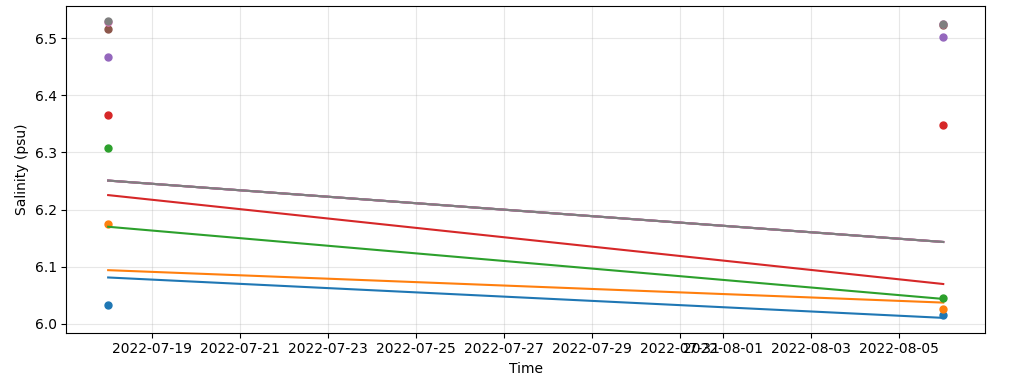


**Profiles of all times**

So, this is a selected time, could include several profiles  
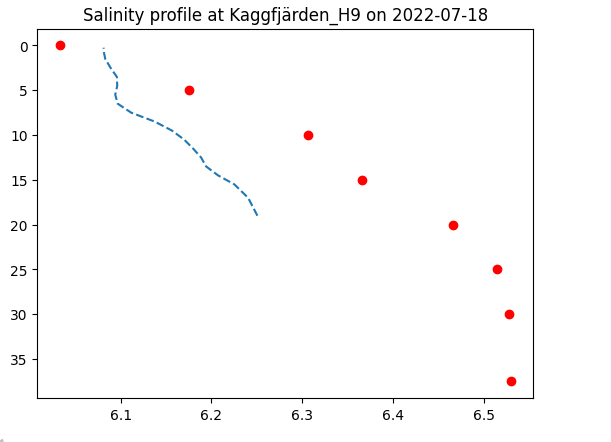

**Havmöller plots**

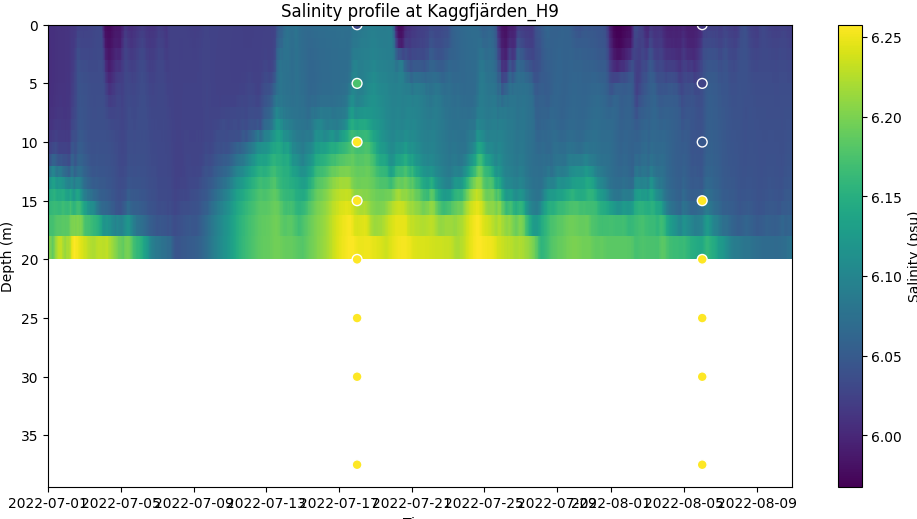

**Vertical statistics**
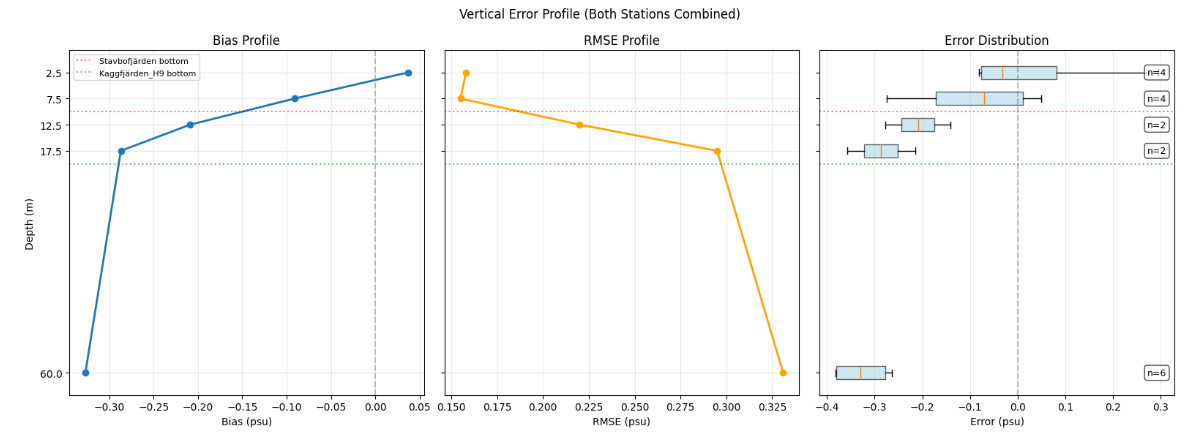

#### Implementation ideas

**Proposal**

1. VerticalObservation class  
    - Stores z coordinate as dimension, x,y as attributes and time
    - Distinguishable from track (x,y coordinates) or point (single x,y,z coordinate)
    - Format for dataframe and dfs
    - Create vertical grid out of all available z
2. Support sigma-levels
    - Need to consider time when matching mod-obs in depth
    - Need layer boundaries in mikeio calc_zf()

3. Matching for verticalObservation needs implementation
    - interpolate mod to obs 
    - or bin obs in model cells
4. from_matched()
    - Consider dataframe structure for creating vertical obs. Is it enough with a column z? Create vertical grid containing all z.

5. Same comparer as today but add support for VerticalObservation
    - plots same as today for all depth (ignoring z coordinate)
    - to_dataframe() include z
    - sel/slice on vertical coordinate
    - vertical_skill(binds, metric) > SkillProfile (1D in z)
6. SkillProfile 
    - xr.Dataset with dim z, with .plot()  or a 
        - producing bias/RMSE vs depth
        - Havmöller? or depth/time (would require raw model)
        - model and obs on depth (Profiles) (would require raw model)

Pros: 
- Reduced code modification/additions. 
- Use same plots etc. as today. 
- Need to add vertical_skill and SkillProfile  

Cons: 
- The comparer plots we have today does not consider vertical. 
- Most plots above will not be supported (maybe only plots in SkillProfile)
- No easy way to aggregate depth

Questions: Do we need new 3dModel class?


Example:
```Python

# ==============================================
# Match mod and obs
# ==============================================

# Create vertical observations
vobs1 = VerticalObservation(df_1, x=, y=)  
vobs2 = VerticalObservation(df_2, x=, y=) #or dfs1?

# Probably need sigma layers support...current model have support for Dfsu3D, Dfsu2H...check this**  
mr = DfsuModelResult(ds, name="HD3D Salinity")   

# Match observations and model results (detects that we use vertical observations)
cmp = match([vobs1, vobs2], mr) 

# ==============================================
# Slicing comparer
# ==============================================

# Select depth levels from comparer (notice that we have z-coordinates in observations)
cmp_sfr = cmp.sel(zmin=0, zmax=15)
cmp_z30_40 = cmp.sel(z=[30, 40])

# or select from area as with other comparers
cmp_sfr_area = cmp.sel(area=(650000, 6.52e6, 668000, 6.54e6))

# or with time slicing
cmp_sfr_time = vcmp.sel(time=slice("2022-07-01", "2022-08-01"))

# ==============================================
# Comparer plots
# ==============================================
# All plots we have today in comparer can be applied to vertical data
# However, no vertical information without slicing the comparer.
# NOTE: most plots today deal with time, no way of plotting time,depth (e.g. havmöller)
v.plot.timeseres()
cmp.plot.box()
...

# Vertical info
cmp_20_30 = cmp.sel(z=[30, 40])
cmp_30_40 = cmp.sel(z=[30, 40])
cmp_30_40.plot.bar()
cmp_20_30.plot.bar()

# ==============================================
# Skill
# ==============================================
# Same as today and same problem as above.
# Comaprer needs to be sliced to get vertical info
cmp_20_30.skill()
cmp.skill()

# ==============================================
# Vertical skill
# ==============================================
sp = cmp.vertical_skill() > SkillProfile

sp.metrics
['n', 'bias', 'rmse', 'urmse', 'mae', 'cc', 'si', 'r2']

#selection
sp.sel(z = [50:100])

# plots
sp.plot.profile() # bias, rmse... plots as seen above (y-axis = depth, x-axis=value)
...

```
**Option:**   
Add VerticalAccessor on Comparer to allow vertical aggregation and dedicated profile plots** 

Reason:
- Supports more plots
- Supports aggregation 
- no need for vertical_skill() on comparer. It is now on vertical

VerticalAccessor:
- vertical.mean(zmin, zmax) > returns collapsed comparer. Ordinary workflow after that
- vertical.slice(depth) > returns collapsed comparer. Ordinary workflow after that
    - Equivalent to creating per‑depth DataFrames manually today.
- vertical.skill(mertrics, ) > SkillProfile  similar to SkillGrid with xarray dataset and z coord and .plot() for lines 
    - Analogous to Comparer.skill() → SkillTable, Comparer.gridded_skill() → SkillGrid (x–y grid)
- vertical.skill(bins|bin_size) (as gridded_skill() but for z)
    - Analogous to spatial binning (gridded_skill) but in 1D (depth).
- vertical.plot.profile() - value vs depth for mod and obs
    - Just like plot.timeseries() but operating in depth space.

Example:
```Python
# Examples:
cmp0_15 = cmp.vertical.mean(zmin=0, zmax=15) #(max, min as well)
cmp0_15.plot.timeseries() #no depth coordinate anymore
cmp0_15.skill()

cmp5m = cmp.vertical.slice(depth=5)
cmp5m.plot.timeseries() 

sp = cmp.vertical.skill(metrics=["rmse", "bias"], bin_size=) #options to bin data
sp.rmse.plot()        # RMSE vs depth
sp.bias.plot()

cmp.vertical.plot.profile(time="2023-07-15T12:00")

cmp.vertical.plot.skill(metric="rmse")


class Comparer:
    ...
    @property
    def vertical(self):
        return VerticalAccessor(self)


class VerticalAccessor:
    def __init__(self, cmp):
        self._cmp = cmp

    def mean(self, zmin, zmax):
        ds = self._cmp.data
        ds2 = _vertical_mean(ds, zmin, zmax)  # returns time-series dataset
        return Comparer.from_matched_dataset(ds2)  # uses existing API

    def slice(self, depth):
        ds = self._cmp.data
        ds2 = _vertical_interpolate(ds, depth)
        return Comparer.from_matched_dataset(ds2)

    def skill(self, metrics=None, bins=None):
        ds = self._cmp.data
        if bins:
            dsb = _vertical_bin(ds, bins)
        else:
            dsb = ds
        sk = _compute_skill_per_depth(dsb, metrics)
        return SkillProfile(sk)

    @property
    def plot(self):
        return VerticalPlotAccessor(self._cmp)

```